**A very good end-to-end GenAI/ML project for your learning path is to build a custom support-ticket classifier:**

Hugging Face pretrained model → your own labeled data → fine-tuning → evaluation → save model → test new text → optionally publish model to Hugging Face Hub

We'll use **DistilBERT** as the pretrained model. Hugging Face's current documentation uses the same general **AutoModelForSequenceClassification** + **Trainer** approach for fine-tuning pretrained transformer models.

**1. What we are going to build**

Our application will classify IT support requests into categories:

| Input                                 | Expected category |
| ------------------------------------- | ----------------- |
| "My laptop is not connecting to WiFi" | NETWORK           |
| "I forgot my password"                | PASSWORD          |
| "Outlook is not sending emails"       | EMAIL             |
| "My laptop screen is broken"          | HARDWARE          |
| "VPN is not connecting"               | NETWORK           |


The architecture will be:


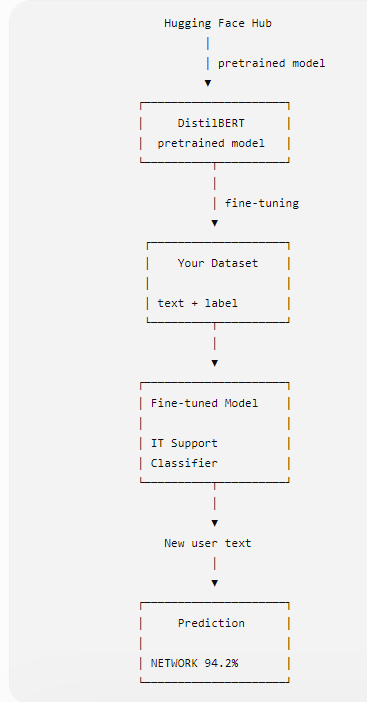

**2. What you will learn**

By completing this Colab project you'll understand:

1.   Hugging Face Hub
2.   Hugging Face authentication
3.   Pretrained models
4.   Tokenizers
5.   Dataset preparation
6.   Train/validation/test split
7.   Transformer fine-tuning
8.   AutoTokenizer
9.   AutoModelForSequenceClassification
10.  TrainingArguments
11.  Trainer
12.  Accuracy evaluation
13.  Confusion matrix
14.  Model inference
15.  Saving the model
16.  Loading the model later
17.  Hugging Face model repository
18.  API-based inference




**3. Google Colab setup**

First, enable GPU:

Runtime → Change runtime type → T4 GPU

Then verify:

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


**4. Install libraries**

In [2]:
!pip install -q --upgrade transformers datasets evaluate accelerate scikit-learn huggingface_hub

We'll use:

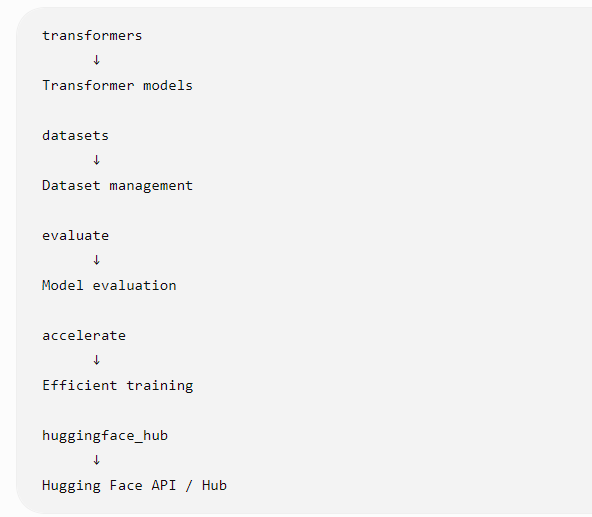

**5. Import libraries**

In [3]:
import os
import numpy as np
import pandas as pd
import torch

from datasets import Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import evaluate

**6. Choose a pretrained Hugging Face model**

We're going to use:
**distilbert/distilbert-base-uncased**
This is a good educational model because it's much lighter than large language models while still being a genuine Transformer architecture.

Define:

In [4]:
MODEL_NAME = "distilbert/distilbert-base-uncased"

print(MODEL_NAME)

distilbert/distilbert-base-uncased


Think of this as:

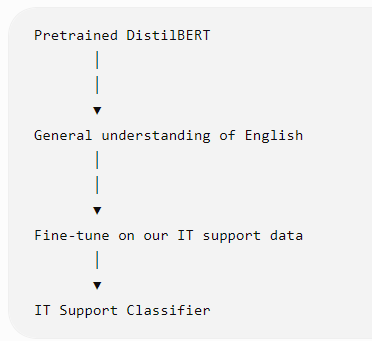

We are **not starting from random weights.**

**7. Create our own dataset**

For this first project, we'll create the data directly in Python.

Later you can replace this with:

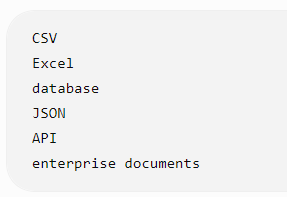

In [5]:
data = [
    # NETWORK
    ("My laptop cannot connect to WiFi", "NETWORK"),
    ("Internet connection is not working", "NETWORK"),
    ("The office network is down", "NETWORK"),
    ("I cannot access the company network", "NETWORK"),
    ("WiFi keeps disconnecting", "NETWORK"),
    ("Network connection is very slow", "NETWORK"),
    ("My computer cannot connect to the internet", "NETWORK"),
    ("VPN connection is failing", "NETWORK"),

    # PASSWORD
    ("I forgot my password", "PASSWORD"),
    ("I need to reset my password", "PASSWORD"),
    ("My account password has expired", "PASSWORD"),
    ("I cannot remember my login password", "PASSWORD"),
    ("Please help me change my password", "PASSWORD"),
    ("My password is not working", "PASSWORD"),
    ("I am locked out of my account", "PASSWORD"),
    ("How can I reset my account password", "PASSWORD"),

    # EMAIL
    ("Outlook is not sending emails", "EMAIL"),
    ("I cannot receive emails", "EMAIL"),
    ("My mailbox is not syncing", "EMAIL"),
    ("Outlook keeps crashing", "EMAIL"),
    ("Email attachments are not downloading", "EMAIL"),
    ("I am not receiving company emails", "EMAIL"),
    ("My Outlook account is not working", "EMAIL"),
    ("Email delivery is failing", "EMAIL"),

    # HARDWARE
    ("My laptop screen is broken", "HARDWARE"),
    ("The keyboard is not working", "HARDWARE"),
    ("My mouse has stopped working", "HARDWARE"),
    ("The laptop will not turn on", "HARDWARE"),
    ("My monitor is showing a black screen", "HARDWARE"),
    ("The computer is making strange noises", "HARDWARE"),
    ("My laptop battery is not charging", "HARDWARE"),
    ("The keyboard keys are not responding", "HARDWARE"),
]

df = pd.DataFrame(data, columns=["text", "label"])

df.head()

,text,label
0,My laptop cannot connect to WiFi,NETWORK
1,Internet connection is not working,NETWORK
2,The office network is down,NETWORK
3,I cannot access the company network,NETWORK
4,WiFi keeps disconnecting,NETWORK


**8. Understand the dataset**

In [6]:
print("Number of examples:", len(df))
print()

print("Classes:")
print(df["label"].value_counts())

Number of examples: 32

Classes:
label
NETWORK     8
PASSWORD    8
EMAIL       8
HARDWARE    8
Name: count, dtype: int64


**9. Convert labels to numbers**

Machine-learning models don't directly work with:

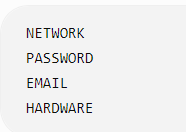

We convert them into IDs.

In [7]:
labels = sorted(df["label"].unique())

label2id = {
    label: idx
    for idx, label in enumerate(labels)
}

id2label = {
    idx: label
    for label, idx in label2id.items()
}

print("label2id:")
print(label2id)

print()

print("id2label:")
print(id2label)

label2id:
{'EMAIL': 0, 'HARDWARE': 1, 'NETWORK': 2, 'PASSWORD': 3}

id2label:
{0: 'EMAIL', 1: 'HARDWARE', 2: 'NETWORK', 3: 'PASSWORD'}


**10. Add numerical labels**

In [8]:
df["label_id"] = df["label"].map(label2id)

df.head()

,text,label,label_id
0,My laptop cannot connect to WiFi,NETWORK,2
1,Internet connection is not working,NETWORK,2
2,The office network is down,NETWORK,2
3,I cannot access the company network,NETWORK,2
4,WiFi keeps disconnecting,NETWORK,2


**11. Split the dataset**

We need:

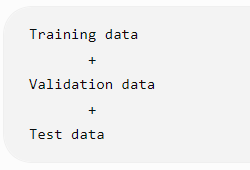

In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label_id"]
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)

print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Training: 22
Validation: 5
Test: 5


Conceptually:

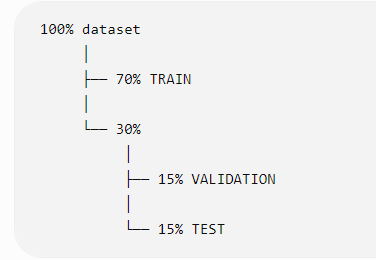

**12. Convert to Hugging Face Dataset**

In [10]:
train_dataset = Dataset.from_pandas(
    train_df[["text", "label_id"]].rename(
        columns={"label_id": "label"}
    ),
    preserve_index=False
)

validation_dataset = Dataset.from_pandas(
    validation_df[["text", "label_id"]].rename(
        columns={"label_id": "label"}
    ),
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label_id"]].rename(
        columns={"label_id": "label"}
    ),
    preserve_index=False
)

dataset = DatasetDict({
    "train": train_dataset,
    "validation": validation_dataset,
    "test": test_dataset
})

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 22
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 5
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 5
    })
})

**13. Load the tokenizer**

This is one of the most important concepts.

A Transformer doesn't directly receive:

**"My laptop is broken"**

It receives tokens converted into numbers.

In [11]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

Test it:

In [12]:
text = "My laptop is not connecting to WiFi"

tokens = tokenizer(text)

print(tokens)

{'input_ids': [101, 2026, 12191, 2003, 2025, 7176, 2000, 15536, 8873, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


The process is:

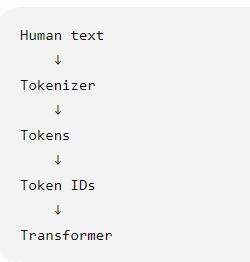

**14. Tokenize the complete dataset**

In [13]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

Now apply it:

In [14]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

tokenized_dataset

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 22
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5
    })
})

Hugging Face recommends tokenizing datasets using the dataset map operation, and dynamic padding can be handled efficiently using a data collator.

**15.** **Data** **collator**

In [15]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

Why do we need this?

Suppose one sentence is:

**I forgot password**

and another:

**My company laptop cannot connect to the wireless network**

They have different lengths.

The data collator dynamically pads them into compatible batches.

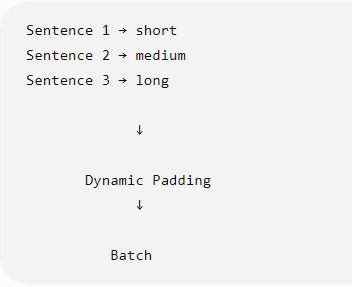

**16. Load pretrained model**

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


This does something very important.

We're taking:

**Pretrained DistilBERT**

and adding a classification head:

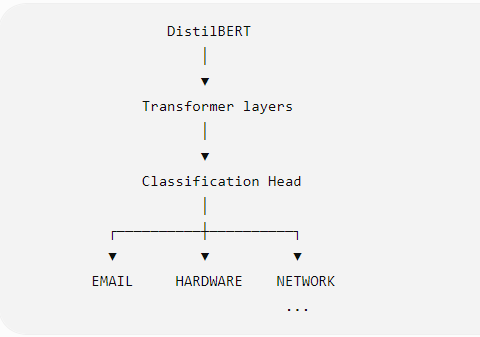

The classification head is adapted to your number of classes. Hugging Face's fine-tuning documentation describes this same pattern: load a pretrained checkpoint and specify the number of labels for the downstream classification task.

**17. Define evaluation metrics**

We want to know:

**How good is my model?**

We'll calculate:

Accuracy
Precision
Recall
F1

In [17]:
def compute_metrics(eval_pred):

    logits, labels_actual = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_actual,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels_actual,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

**18. Configure training**

In [18]:
training_args = TrainingArguments(
    output_dir="./it-support-model",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=10,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    logging_steps=5,

    report_to="none",

    fp16=torch.cuda.is_available()
)

**19. Create Trainer**

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],

    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

Think of **Trainer** as managing:

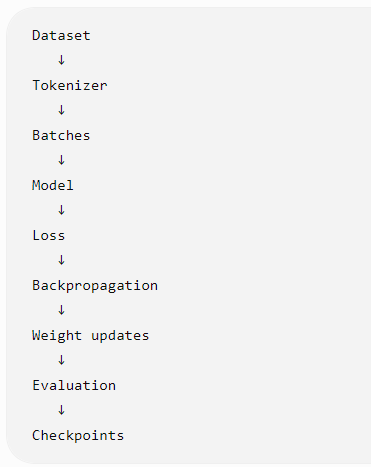

Hugging Face's **Trainer** is specifically designed to handle this fine-tuning workflow.

**20. Start training**

In [20]:
training_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,1.378711,0.200000,0.040000,0.200000,0.066667
2,1.383797,1.365625,0.400000,0.450000,0.400000,0.346667
3,1.383797,1.349805,0.600000,0.600000,0.600000,0.533333
4,1.337687,1.330469,0.400000,0.450000,0.400000,0.346667
5,1.244116,1.309570,0.400000,0.450000,0.400000,0.346667
6,1.244116,1.286719,0.400000,0.450000,0.400000,0.346667
7,1.152681,1.266406,0.400000,0.466667,0.400000,0.366667
8,1.152681,1.249414,0.400000,0.466667,0.400000,0.366667
9,1.141776,1.237988,0.400000,0.466667,0.400000,0.366667
10,1.068282,1.233398,0.400000,0.466667,0.400000,0.366667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

**21. Evaluate the model**

In [21]:
evaluation_result = trainer.evaluate()

print(evaluation_result)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
1.068282,1.233398,10,0.400000,0.466667,0.400000,0.366667


{'eval_loss': 1.2333984375, 'eval_accuracy': 0.4, 'eval_precision': 0.4666666666666667, 'eval_recall': 0.4, 'eval_f1': 0.36666666666666664}


**22. Test using completely new data**

In [22]:
test_sentences = [
    "My wireless internet keeps dropping",
    "I need help resetting my login",
    "Outlook is unable to send my messages",
    "The screen on my laptop is damaged"
]

Create inference pipeline:

In [23]:
classifier = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

Run predictions:

In [24]:
predictions = classifier(test_sentences)

for text, prediction in zip(test_sentences, predictions):

    print("Text:", text)
    print("Prediction:", prediction["label"])
    print("Confidence:", round(prediction["score"], 4))
    print("-" * 60)

Text: My wireless internet keeps dropping
Prediction: NETWORK
Confidence: 0.3074
------------------------------------------------------------
Text: I need help resetting my login
Prediction: PASSWORD
Confidence: 0.3723
------------------------------------------------------------
Text: Outlook is unable to send my messages
Prediction: PASSWORD
Confidence: 0.303
------------------------------------------------------------
Text: The screen on my laptop is damaged
Prediction: HARDWARE
Confidence: 0.3225
------------------------------------------------------------


**23. Test the actual held-out test set**

This is more important than testing hand-picked examples.

In [25]:
test_results = trainer.predict(
    tokenized_dataset["test"]
)

predicted_ids = np.argmax(
    test_results.predictions,
    axis=-1
)

actual_ids = test_results.label_ids

print(
    classification_report(
        actual_ids,
        predicted_ids,
        target_names=labels,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       EMAIL       1.00      0.50      0.67         2
    HARDWARE       1.00      1.00      1.00         1
     NETWORK       1.00      1.00      1.00         1
    PASSWORD       0.50      1.00      0.67         1

    accuracy                           0.80         5
   macro avg       0.88      0.88      0.83         5
weighted avg       0.90      0.80      0.80         5



**24. Confusion matrix**

This is extremely useful in real ML projects.

In [26]:
cm = confusion_matrix(
    actual_ids,
    predicted_ids
)

print(cm)

[[1 0 0 1]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


You can visualize it:

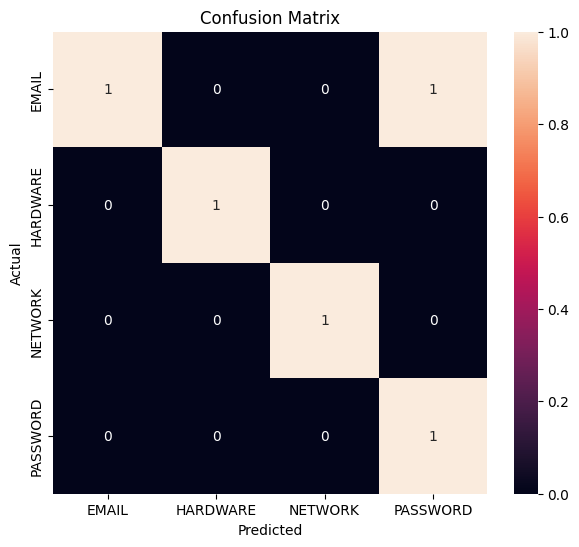

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**25. Build a reusable prediction function**

Instead of manually calling the pipeline every time:

In [28]:
def predict_ticket(text):

    result = classifier(text)[0]

    return {
        "text": text,
        "category": result["label"],
        "confidence": round(result["score"], 4)
    }

Test it:

In [29]:
result = predict_ticket(
    "I cannot connect my computer to the office WiFi"
)

print(result)

{'text': 'I cannot connect my computer to the office WiFi', 'category': 'NETWORK', 'confidence': 0.3124}


**26. Create a simple AI application**

Now we turn our model into an actual application.

In [30]:
while True:

    user_input = input(
        "\nEnter IT support issue "
        "(type 'exit' to stop): "
    )

    if user_input.lower() == "exit":
        break

    result = predict_ticket(user_input)

    print("\nAI Prediction")
    print("----------------------")
    print("Category:", result["category"])
    print("Confidence:", result["confidence"])


Enter IT support issue (type 'exit' to stop): exit


**27. Save your trained model**

This is extremely important.

You don't want to retrain the model every time.

In [31]:
MODEL_OUTPUT = "./final-it-support-model"

trainer.save_model(MODEL_OUTPUT)

tokenizer.save_pretrained(
    MODEL_OUTPUT
)

print("Model saved to:", MODEL_OUTPUT)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./final-it-support-model


**28. Load the model again**

This demonstrates an important production concept.

You can restart the application and load the trained model without training again.

In [32]:
loaded_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_OUTPUT
)

loaded_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_OUTPUT
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Create inference pipeline:

In [33]:
loaded_classifier = pipeline(
    "text-classification",
    model=loaded_model,
    tokenizer=loaded_tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

Test:

In [34]:
loaded_classifier(
    "My password has expired"
)

[{'label': 'PASSWORD', 'score': 0.4612172245979309}]

**29. Connect your application to Hugging Face**

This is where the Hugging Face API/Hub becomes important.

You need a Hugging Face account and an access token.

Hugging Face recommends user access tokens for authenticating applications and notebooks; a read token is sufficient for reading models, while write access is needed when pushing model repositories.

Create your token from:

[Hugging Face Access Tokens](https://huggingface.co/settings/tokens?utm_source=chatgpt.com)

For uploading your trained model, use a token with appropriate write access.

**30. Login from Colab**

In [35]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from huggingface_hub import whoami

print(whoami())

**31. Push your model to Hugging Face Hub**

You can now upload the fine-tuned model.

In [ ]:
from google.colab import userdata

HF_UserName = userdata.get('HF_UserName')
print(HF_UserName)



In [ ]:
# from huggingface_hub import HfApi

# api = HfApi()

# api.create_repo(
#     repo_id=f"{HF_UserName}/it-support-classifier",
#     repo_type="model",
#     exist_ok=True
# )

In [ ]:

HF_REPO = f"{HF_UserName}/it-support-classifier"
trainer.push_to_hub(
    HF_REPO
)

**32. Load your model directly from Hugging Face**

This is an important production concept.

Once uploaded, you don't need:

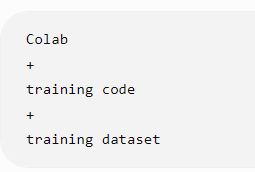

to make predictions.

You can simply load:

In [40]:
MODEL_NAME = f"{HF_UserName}/it-support-model"

In [41]:
from transformers import pipeline

remote_classifier = pipeline(
    "text-classification",
    model=MODEL_NAME
)

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

In [42]:
remote_classifier(
    "My laptop cannot connect to WiFi"
)

[{'label': 'NETWORK', 'score': 0.3459324240684509}]

The Hugging Face Hub becomes your model registry.

**33. Hugging Face API inference**

There is another concept you should understand.

Instead of loading the entire model locally, Hugging Face provides inference capabilities through its APIs/providers. The current Hugging Face documentation provides InferenceClient for programmatic inference and supports authentication using a Hugging Face token.

For example:

In [ ]:
from huggingface_hub import InferenceClient
import os

HF_TOKEN = os.environ["HF_TOKEN"]

client = InferenceClient(
    api_key=HF_TOKEN
)

The important architecture is:

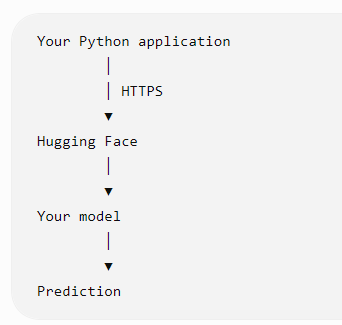

**34. The complete project architecture**

After completing the notebook, you should understand this architecture:

                         HUGGING FACE HUB
                              │
                              │
                       Pretrained Model
                              │
                              ▼
                  ┌─────────────────────┐
                  │     DistilBERT      │
                  │                     │
                  │ Pretrained weights  │
                  └──────────┬──────────┘
                             │
                             │ Fine-tuning
                             ▼
                    ┌────────────────┐
                    │ Your Dataset   │
                    │                │
                    │ Text + Label   │
                    └───────┬────────┘
                            │
                            ▼
                  ┌─────────────────────┐
                  │   Fine-tuned Model  │
                  │                     │
                  │ IT Support AI       │
                  └──────────┬──────────┘
                             │
                  ┌──────────┴───────────┐
                  │                      │
                  ▼                      ▼
             Local model          Hugging Face Hub
                  │                      │
                  ▼                      ▼
             Python app             API / Cloud
                  │                      │
                  └──────────┬───────────┘
                             ▼
                         Prediction

**35. What is actually happening during training?**

This is probably the most important conceptual part.

Suppose we have:

**"My VPN is not connecting"**

Our expected label is:

NETWORK

First:

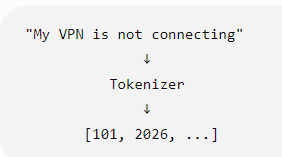

Then:

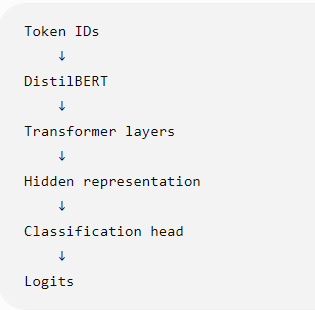

Suppose the model initially produces:

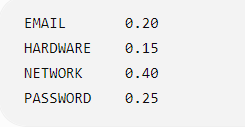

Expected:

**NETWORK**

The training process calculates the error:

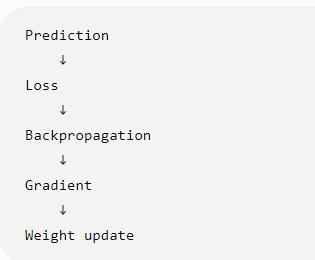

After many examples:

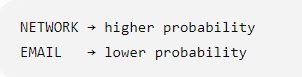

Eventually:

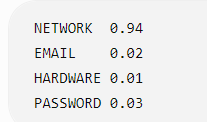

That's fine-tuning.